In [1]:
import pyomo.environ as pyo
import numpy as np
import pandas as pd
import pandapower.networks as pn
import matplotlib.pyplot as plt
import math
from collections import defaultdict
from datetime import timedelta
from pyomo.util.infeasible import log_infeasible_constraints
from pathlib import Path
import warnings
from pyomo.opt import TerminationCondition
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
class charging_point():
    def __init__(self, name, ev_id, session_id, ev_capacity, ev_max_power, ev_arrival_soc, ev_arrival, ev_departure, ev_desired_soc):
        self.efficiency = 0.93
        # Input validation using assertions
        assert isinstance(ev_capacity, list), "ev_capacity must be a list"
        assert isinstance(ev_max_power, list), "ev_max_power must be a list"
        assert isinstance(ev_arrival_soc, list), "ev_arrival_soc must be a list"
        assert isinstance(ev_arrival, list), "ev_arrival must be a list"
        assert isinstance(ev_departure, list), "ev_departure must be a list"
        assert isinstance(ev_desired_soc, list), "ev_desired_soc must be a list"

        assert len(ev_arrival) == len(ev_departure), "ev_arrival and ev_departure must have the same length"
        assert len(ev_arrival) == len(ev_desired_soc), "ev_arrival and ev_desired_soc must have the same length"
        assert len(ev_arrival_soc) == len(ev_desired_soc), "ev_arrival_soc and ev_desired_soc must have the same length"
        assert len(ev_capacity) == len(ev_desired_soc), "ev_capacity and ev_desired_soc must have the same length"
        assert len(ev_max_power) == len(ev_desired_soc), "ev_max_power and ev_desired_soc must have the same length"

        for i in range(len(ev_arrival)):
            assert ev_arrival[i] < ev_departure[i], f"ev_arrival[{i}] must be less than ev_departure[{i}]"
            assert 0.2 <= ev_arrival_soc[i] <= 1, f"ev_arrival_soc[{i}] must be between 0.2 and 1"
            assert 0 <= ev_desired_soc[i] <= 1, f"ev_desired_soc[{i}] must be between 0 and 1"
            min_time_to_charge = ev_departure[i] - ev_arrival[i]
            min_req_charge = (ev_desired_soc[i] - ev_arrival_soc[i]) * ev_capacity[i] / self.efficiency
            min_req_charge_per_time = min_req_charge / min_time_to_charge
            assert min_req_charge_per_time <= ev_max_power[i], f"min_req_charge_per_time ({min_req_charge_per_time:.2f}) must be less than or equal to ev_max_power[{i}] ({ev_max_power[i]}) for {name}"
            if min_req_charge_per_time * 4 >= ev_max_power[i]:
                warnings.warn(f"Charging would not work for 15-min resolution for {name}")


        self.name = name
        self.ev_capacity = ev_capacity
        self.ev_max_power = ev_max_power
        self.ev_arrival_soc = ev_arrival_soc
        self.ev_desired_soc = ev_desired_soc
        self.ev_arrival = ev_arrival
        self.ev_departure = ev_departure
        self.num_evs = len(ev_capacity) # Store the number of EVs
        self.ev_id = ev_id
        self.session_id = session_id

class building():
    def __init__(self, name, load, pv_production, bess_capacity, bess_max_power, bess_initial_soc):
        self.efficiency = 0.93
        self.name = name
        self.load = load
        self.pv_production = pv_production
        self.bess_capacity = bess_capacity
        self.bess_max_power = bess_max_power
        self.bess_initial_soc = bess_initial_soc


class lec_opt():
    def __init__(self, charging_points, buildings, spot_prices, flex_price, P_dso_import,
                 P_dso_export, previous_monthly_peak=0, v2g_on=1, incentive_per_kwh=0.1, roh=0.1, resolution = 4):
        self.M = 10000
        self.roh = roh
        self.charging_points = charging_points
        self.buildings = buildings
        self.spot_prices = spot_prices
        self.incentive_per_kwh = incentive_per_kwh
        self.v2g_on = v2g_on
        self.previous_monthly_peak = previous_monthly_peak
        self.flex_price = flex_price
        self.P_dso_import = P_dso_import
        self.P_dso_export = P_dso_export
        self.resolution = resolution
        self.model = pyo.ConcreteModel()
        self.build_model()

    def build_model(self):
        self.model.T = pyo.Set(initialize=range(len(self.spot_prices)))
        self.model.spot_prices = self.spot_prices
        self.model.previous_monthly_peak = self.previous_monthly_peak
        self.model.monthly_peak = pyo.Var(initialize=0)
        self.model.P_im_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 20000))
        self.model.P_ex_grid = pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 20000))
        self.model.B_im_grid = pyo.Var(self.model.T, within=pyo.Binary)
        self.model.Peakload = pyo.Var(within=pyo.NonNegativeReals)
        self.model.transmission_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.supplier_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.overall_dso_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.tax_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.overall_cost = pyo.Var(within = pyo.Reals)
        self.model.peak_cost = pyo.Var(self.model.T, within=pyo.Reals)
        self.model.Subscription_fee = 605 / 30  # Subscription fee SEK/14 days
        self.model.Transmission_fee = 0.113  # Electricity transmission fee SEK/kWh
        self.model.Transmission_health_incentive = 0.04  # Transmission health incentive SEK/kWh
        self.model.Effect_fee = 61.55 / 30  # Effect fee SEK/kW/14 days
        self.model.Energy_tax = 0.439  # Tax fee SEK/kWh
        self.model.Energy_certificate = 0.005  # Energy certificate SEK/kWh
        self.model.compensation_fee = 0.02  # Transfer compensation fee SEK/kWh

        for charge_point in self.charging_points:
            setattr(self.model, f'{charge_point.name}_P', pyo.Var(self.model.T, within=pyo.Reals, bounds=(-1000000, 1000000)))

            # Iterate through each EV at the charging point
            for ev_index in range(len(charge_point.session_id)):
                ev_name = f'{charge_point.name}_S{charge_point.session_id[ev_index]}'  # Unique name for each EV
                setattr(self.model, f'{ev_name}_ch', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, charge_point.ev_max_power[ev_index])))
                setattr(self.model, f'{ev_name}_ds', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, self.v2g_on * charge_point.ev_max_power[ev_index])))
                setattr(self.model, f'{ev_name}_soc', pyo.Var(self.model.T, within=pyo.NonNegativeReals, bounds=(0, 1)))
                setattr(self.model, f'{ev_name}_Bch', pyo.Var(self.model.T, within=pyo.Binary))

                ev_capacity = charge_point.ev_capacity[ev_index]
                ev_arrival_soc = charge_point.ev_arrival_soc[ev_index]
                ev_arrival = charge_point.ev_arrival[ev_index]
                ev_departure = charge_point.ev_departure[ev_index]
                ev_desired_soc = charge_point.ev_desired_soc[ev_index]

                def ev_soc_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == ev_arrival:
                        return ev_soc == ev_arrival_soc + (ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity / self.resolution
                    elif ev_arrival < t <= ev_departure:
                        ev_previous_soc = getattr(model, f'{ev_name}_soc')[t - 1]
                        return ev_soc == ev_previous_soc + (ev_ch * charge_point.efficiency - ev_ds / charge_point.efficiency) / ev_capacity / self.resolution
                    else:
                        return pyo.Constraint.Skip
                setattr(self.model, f'{ev_name}_soc_constraint', pyo.Constraint(self.model.T, rule=ev_soc_rule))

                def ev_soc_min_rule(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    ev_arrival = charge_point.ev_arrival[ev_index]
                    ev_departure = charge_point.ev_departure[ev_index]
                    if ev_arrival <= t <= ev_departure:
                        return ev_soc >= 0.2
                    return ev_soc == 0
                setattr(self.model, f'{ev_name}_soc_min_constraint', pyo.Constraint(self.model.T, rule=ev_soc_min_rule))

                def ev_max_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    return ev_ch <= ev_Bch * charge_point.ev_max_power[ev_index]
                setattr(self.model, f'{ev_name}_max_ch_constraint', pyo.Constraint(self.model.T, rule=ev_max_ch))

                def ev_max_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_Bch = getattr(model, f'{ev_name}_Bch')[t]
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    return ev_ds <= (1 - ev_Bch) * charge_point.ev_max_power[ev_index]
                setattr(self.model, f'{ev_name}_max_ds_constraint', pyo.Constraint(self.model.T, rule=ev_max_ds))

                def ev_avail_ch(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ch = getattr(model, f'{ev_name}_ch')[t]
                    if charge_point.ev_arrival[ev_index] <= t < charge_point.ev_departure[ev_index]:
                        return ev_ch >= 0
                    return ev_ch == 0
                setattr(self.model, f'{ev_name}_avail_ch_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ch))

                def ev_avail_ds(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_ds = getattr(model, f'{ev_name}_ds')[t]
                    if charge_point.ev_arrival[ev_index] <= t < charge_point.ev_departure[ev_index]:
                        return ev_ds >= 0
                    return ev_ds == 0
                setattr(self.model, f'{ev_name}_avail_ds_constraint', pyo.Constraint(self.model.T, rule=ev_avail_ds))

                def ev_desired_soc(model, t, charge_point=charge_point, ev_index=ev_index):
                    ev_soc = getattr(model, f'{ev_name}_soc')[t]
                    if t == charge_point.ev_departure[ev_index]:
                        return ev_soc >= charge_point.ev_desired_soc[ev_index]
                    return pyo.Constraint.Skip
                setattr(self.model, f'{ev_name}_desired_soc_constraint', pyo.Constraint(self.model.T, rule=ev_desired_soc))

            def consumption(model, t, charge_point=charge_point):
                P = getattr(model, f'{charge_point.name}_P')[t]
                ev_power = sum(getattr(model, f'{charge_point.name}_S{charge_point.session_id[ev_index]}_ch')[t] - getattr(model, f'{charge_point.name}_S{charge_point.session_id[ev_index]}_ds')[t] for ev_index in range(charge_point.num_evs))
                return  ev_power == P
            setattr(self.model, f'{charge_point.name}_consumption_constraint', pyo.Constraint(self.model.T, rule=consumption))
        
        #Building constraints:
        for building in self.buildings:
            setattr(self.model, f'{building.name}_P', pyo.Var(self.model.T, within=pyo.Reals, bounds=(-1000000, 1000000)))
            setattr(self.model, f'{building.name}_bess_soc', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, 1)))
            setattr(self.model, f'{building.name}_bess_ch', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_ds', pyo.Var(self.model.T, within=pyo.Reals, bounds=(0, building.bess_max_power)))
            setattr(self.model, f'{building.name}_bess_Bch', pyo.Var(self.model.T, within=pyo.Binary))

            def bess_soc_rule(model, t, building = building):
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                elif t == 0:
                    return bess_soc == building.bess_initial_soc + (bess_ch*building.efficiency - bess_ds/building.efficiency)/building.bess_capacity
                else:
                    bess_previous_soc = getattr(model, f'{building.name}_bess_soc')[t-1]
                    return bess_soc == bess_previous_soc + (bess_ch*building.efficiency - bess_ds/building.efficiency)/building.bess_capacity
            setattr(self.model, f'{building.name}_bess_soc_constraint', pyo.Constraint(self.model.T, rule = bess_soc_rule))

            def bess_soc_min_rule(model, t, building = building):
                bess_soc = getattr(model, f'{building.name}_bess_soc')[t]
                if building.bess_capacity == 0:
                    return bess_soc == 0
                return bess_soc >= 0.2
            setattr(self.model, f'{building.name}_bess_soc_min_constraint', pyo.Constraint(self.model.T, rule = bess_soc_min_rule))  

            def bess_max_ch(model, t, building = building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                if building.bess_capacity == 0:
                    return bess_ch == 0
                return bess_ch <= bess_Bch*building.bess_max_power
            setattr(self.model, f'{building.name}_bess_max_ch_constraint', pyo.Constraint(self.model.T, rule = bess_max_ch))

            def bess_max_ds(model, t, building = building):
                bess_Bch = getattr(model, f'{building.name}_bess_Bch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                if building.bess_capacity == 0:
                    return bess_ds == 0
                return bess_ds <= (1-bess_Bch)*building.bess_max_power
            setattr(self.model, f'{building.name}_bess_max_ds_constraint', pyo.Constraint(self.model.T, rule = bess_max_ds))

            def building_consumption(model, t, building = building):
                P = getattr(model, f'{building.name}_P')[t]
                load = building.load[t]
                pv = building.pv_production[t]
                bess_ch = getattr(model, f'{building.name}_bess_ch')[t]
                bess_ds = getattr(model, f'{building.name}_bess_ds')[t]
                return load - pv - bess_ds + bess_ch == P
            setattr(self.model, f'{building.name}_consumption_constraint', pyo.Constraint(self.model.T, rule = building_consumption))

        def power_balance(model, t):
            overall_consumption = sum(getattr(model, f'{charge_point.name}_P')[t] for charge_point in self.charging_points) + \
                                    sum(getattr(model, f'{building.name}_P')[t] for building in self.buildings)
            P_im = self.model.P_im_grid[t]
            P_ex = self.model.P_ex_grid[t]
            return P_im - P_ex == overall_consumption
        self.model.power_balance_constarint = pyo.Constraint(self.model.T, rule=power_balance)

        def power_import(model, t):
            P_im = self.model.P_im_grid[t]
            B_im = self.model.B_im_grid[t]
            return P_im <= self.M * B_im
        self.model.power_import_constraint = pyo.Constraint(self.model.T, rule=power_import)

        def power_export(model, t):
            P_ex = self.model.P_ex_grid[t]
            B_im = self.model.B_im_grid[t]
            return P_ex <= self.M * (1 - B_im)
        self.model.power_export_constraint = pyo.Constraint(self.model.T, rule=power_export)

        def peak_load_constraint(model, t):
            return model.Peakload >= model.P_im_grid[t] - model.P_ex_grid[t]
        self.model.peak_load_constraint = pyo.Constraint(self.model.T, rule=peak_load_constraint)

        def previous_peak_check1(model):
            return model.monthly_peak >= model.Peakload
        self.model.previous_peak_check1_constraint = pyo.Constraint(rule=previous_peak_check1)

        def previous_peak_check2(model):
            return model.monthly_peak >= model.previous_monthly_peak
        self.model.previous_peak_check2_constraint = pyo.Constraint(rule=previous_peak_check2)

        def tranmission_cost(model, t):
            return model.transmission_cost[t] == (model.P_im_grid[t] * model.Transmission_fee - model.P_ex_grid[t] * model.Transmission_health_incentive) / self.resolution
        self.model.tranmission_cost_constraint = pyo.Constraint(self.model.T, rule = tranmission_cost)

        def supplier_cost(model, t):
            return model.supplier_cost[t] == (model.P_im_grid[t] * (model.spot_prices[t] + model.Energy_certificate) - model.P_ex_grid[t] * (model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)) / self.resolution
        self.model.supplier_cost_constraint = pyo.Constraint(self.model.T, rule = supplier_cost)

        def overall_cost(model):

            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t] / 4 - (
                        model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)
                                * model.P_ex_grid[t] / 4 for t in model.T)
            transmission_cost = sum(
                (model.Transmission_fee) * model.P_im_grid[t] / 4 - (model.Transmission_health_incentive)
                * model.P_ex_grid[t] / 4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * 0.25
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost) * 0.25 + (
                        1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)
            overall_cost = dso_cost + tax_cost + supplier_cost
            return overall_cost == self.model.overall_cost
        self.model.overall_cost_constraint = pyo.Constraint(rule = overall_cost)

        # Base objective: without flex_income and penalty_cost
        def base_objective_rule(model):
            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t] / 4 - (
                        model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)
                                * model.P_ex_grid[t] / 4 for t in model.T)
            transmission_cost = sum(
                (model.Transmission_fee) * model.P_im_grid[t] / 4 - (model.Transmission_health_incentive)
                * model.P_ex_grid[t] / 4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * 0.25
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost) * 0.25 + (
                        1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)
            overall_cost = dso_cost + tax_cost + supplier_cost
            return overall_cost

        self.model.base_obj = pyo.Objective(rule=base_objective_rule, sense=pyo.minimize)

        # Extended objective: with flex_income and penalty_cost 
        def extended_obj_rule(model):
            subscription_fee = model.Subscription_fee
            supplier_cost = sum((model.spot_prices[t] + model.Energy_certificate) * model.P_im_grid[t] / 4 - (
                        model.spot_prices[t] + model.Energy_certificate + model.compensation_fee)
                                * model.P_ex_grid[t] / 4 for t in model.T)
            transmission_cost = sum(
                (model.Transmission_fee) * model.P_im_grid[t] / 4 - (model.Transmission_health_incentive)
                * model.P_ex_grid[t] / 4 for t in model.T)
            peak_cost = model.Effect_fee * model.monthly_peak * 0.25
            dso_cost = transmission_cost + peak_cost + subscription_fee
            tax_cost = (supplier_cost + dso_cost) * 0.25 + (
                        1.25 * model.Energy_tax * sum(model.P_im_grid[t] - model.P_ex_grid[t] for t in model.T) / 4)

            penalty_cost = (sum(self.flex_price[t] * ((model.P_im_grid[t] - model.P_ex_grid[t]) +  #SHOULD THE PENALTY WITH FLEX PRICE BE ON DIFFERENCE BETWEEN DSO AND LEC OR ONLY LEC?
                                                      (self.P_dso_import[t] - self.P_dso_export[t])) for t in model.T)
                            + (self.roh / 2) * sum(
                ((model.P_im_grid[t] - model.P_ex_grid[t]) +
                 (self.P_dso_import[t] - self.P_dso_export[t]))** 2 for t in model.T))
            overall_cost = dso_cost + tax_cost + supplier_cost + penalty_cost
            return overall_cost

        self.model.extended_obj = pyo.Objective(rule=extended_obj_rule, sense=pyo.minimize)

    def solve(self, use_extended=False):
        solver = pyo.SolverFactory('gurobi')
        if use_extended:
            self.model.base_obj.deactivate()
            self.model.extended_obj.activate()
        else:
            self.model.extended_obj.deactivate()
            self.model.base_obj.activate()

        self.results = solver.solve(self.model)
        return self.results

    def get_results(self):
        #print(f'Objective value: {pyo.value(self.model.obj)}')
        #print(f"⏱ Time steps in model: {len(self.model.T)}")
        results = {}
        for cp in self.charging_points:
            T = list(self.model.T)
            ch = []
            ds = []
            soc = []
            ev_connection = []
            session_connection = []

            for t in T:
                ch_t = 0.0
                ds_t = 0.0
                connected_evs_t = None
                soc_ev_t = 0.0
                session_id_t = None

                for ev in range(cp.num_evs):
                    ev_name = f"{cp.name}_S{cp.session_id[ev]}"

                    ch_t += pyo.value(getattr(self.model, f"{ev_name}_ch")[t])
                    ds_t += pyo.value(getattr(self.model, f"{ev_name}_ds")[t])

                    soc_ev = pyo.value(getattr(self.model, f"{ev_name}_soc")[t])
                    soc_ev_t += soc_ev

                    if cp.ev_arrival[ev] <= t < cp.ev_departure[ev]:
                        connected_evs_t = cp.ev_id[ev]
                        session_id_t = cp.session_id[ev]
                
                ev_connection.append(connected_evs_t)
                session_connection.append(session_id_t)

                ch.append(ch_t)
                ds.append(ds_t)
                soc.append(soc_ev_t)

            # ---------- STORE CP-LEVEL RESULTS ----------
            results[f"{cp.name}_EV_connection"] = ev_connection
            results[f"{cp.name}_Session"] = session_connection
            results[f"{cp.name}_ch"] = ch
            results[f"{cp.name}_ds"] = ds
            results[f"{cp.name}_soc"] = soc

            # ---------- EXISTING CP VARIABLES ----------
            results[f"{cp.name}_P"] = [pyo.value(getattr(self.model, f"{cp.name}_P")[t]) for t in T]

        for building in self.buildings:
            results[f'{building.name}_bess_ch'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ch')[t]) for t in self.model.T]
            results[f'{building.name}_bess_ds'] = [pyo.value(getattr(self.model, f'{building.name}_bess_ds')[t]) for t in self.model.T]
            results[f'{building.name}_bess_soc'] = [pyo.value(getattr(self.model, f'{building.name}_bess_soc')[t]) for t in self.model.T]
            results[f'{building.name}_PV'] = [building.pv_production[t] for t in self.model.T]
            results[f'{building.name}_Load'] = [building.load[t] for t in self.model.T]
            results[f'{building.name}_P'] = [pyo.value(getattr(self.model, f'{building.name}_P')[t]) for t in self.model.T]
        results['P_import'] = [pyo.value(self.model.P_im_grid[t]) for t in self.model.T]
        results['P_export'] = [pyo.value(self.model.P_ex_grid[t]) for t in self.model.T]
        results['Transmission cost'] = [pyo.value(self.model.transmission_cost[t]) for t in self.model.T]
        results['Supplier cost'] = [pyo.value(self.model.supplier_cost[t]) for t in self.model.T]
        results['Flex prices'] = [pyo.value(self.flex_price[t]) for t in self.model.T]
        results['obj'] = pyo.value(self.model.overall_cost)
        results['Spot prices'] = [pyo.value(self.spot_prices[t]) for t in self.model.T]
        return pd.DataFrame(results)

In [3]:
class DSO:
    def __init__(self, flex_price, P_lec_imp, P_lec_exp, VOLL,
                 S_base_MVA=100, V_base_kV=11, roh=0.1, resolution = 1, horizon_hours = 24):
        self.T = horizon_hours * resolution
        self.buses = {}
        self.lines = {}
        self.loads = {}
        self.lecs = {}

        # Grid import/export limits in kW
        self.grid_limit = 1000

        # Input data (all in kW)
        self.flex_price = flex_price
        self.P_lec_imp = P_lec_imp  # dict keyed by (t, bus)
        self.P_lec_exp = P_lec_exp  # dict keyed by (t, bus)
        self.VOLL = VOLL
        self.roh = roh

        # Per-unit conversion bases
        self.S_base_MVA = S_base_MVA
        self.S_base_kW = S_base_MVA * 1000  # Convert to kW
        self.V_base_kV = V_base_kV

    # -----------------------
    # System definitions
    # -----------------------
    def add_buses(self, bus_df):
        """Add buses from DataFrame with columns: Bus, Type"""
        for _, row in bus_df.iterrows():
            self.buses[row['Bus']] = {'Type': row['Type']}

    def add_lines(self, line_df):
        """
        Add lines from DataFrame
        Expected columns: From, To, X_ohm, Pline_limit
        Converts reactance to per-unit based on S_base and V_base
        """
        for _, row in line_df.iterrows():
            line_id = f"{row['From']}_{row['To']}"
            # Convert ohms to per-unit: X_pu = X_ohm * S_base / V_base^2
            # (using same simplified unit treatment as originally)
            X_pu = row['X_ohm'] * self.S_base_MVA / (self.V_base_kV ** 2)
            self.lines[line_id] = {
                'from': row['From'],
                'to': row['To'],
                'X_pu': X_pu,
                'X_ohm': row['X_ohm'],
                'Pline_limit': row['Pline_limit']
            }

    def add_loads(self, load_df):
        """
        Add loads from DataFrame
        Expected columns: Bus, 0, 1, 2, ..., T-1 (loads in kW)
        """
        T = self.T
        for _, row in load_df.iterrows():
            bus = row['Bus']
            for t in range(T):
                if t not in row.index:
                    raise KeyError(f"Missing column {t} in load_df")
                self.loads[(bus, t)] = row[t]  # kW

    def add_lecs(self, lec_bus_list):
        """Define which buses have LECs"""
        for b in lec_bus_list:
            self.lecs[b] = True

    def set_grid_limit(self, p_grid_limit=1000):
        """Set grid import/export limit in kW"""
        self.grid_limit = p_grid_limit

    def validate_data(self):
        """Validate that required data is present"""
        if not self.buses:
            raise ValueError("No buses defined.")
        if not self.loads:
            raise ValueError("No loads defined.")
        slack_buses = [b for b, info in self.buses.items() if info['Type'] == 'slack']
        if not slack_buses:
            raise ValueError("No slack bus defined.")
    
    def add_connection_points(self, cp_dict):
        self.connection_points = {}
        for bus_num, cps in cp_dict.items():
            bus_name = f'B{bus_num}'
            cp_list = [f'cp{cp}' for cp in sorted(cps)]
            self.connection_points[bus_name] = cp_list

    # -----------------------
    # Build DC OPF model
    # -----------------------
    def build_dc_opf(self):
        """Build the DC Optimal Power Flow model with proper unit handling"""
        self.validate_data()

        model = pyo.ConcreteModel()
        T = self.T

        model.T = pyo.Set(initialize=range(T))
        model.B = pyo.Set(initialize=list(self.buses.keys()))
        model.L = pyo.Set(initialize=list(self.lines.keys()))

        cp_list = []
        for b in model.B:
            b_str = str(b)
            if b_str in self.connection_points:
                for cp in self.connection_points[b]:
                    cp_list.append((b, cp))
        
        model.BCP = pyo.Set(initialize = cp_list, dimen = 2)

        slack_bus = [b for b, info in self.buses.items() if info['Type'] == 'slack'][0]

        # -------------------------
        # Variables (all in kW except angles)
        # -------------------------
        model.Pshed = pyo.Var(model.T, model.B, within=pyo.NonNegativeReals)

        # Voltage angles in radians (unbounded is also OK but keep reasonable bounds)
        model.theta = pyo.Var(model.T, model.B, bounds=(-np.pi, np.pi))

        # Line flows in kW (will convert to/from per-unit internally)
        # Individual line limits will be enforced with constraints below.
        model.P_line = pyo.Var(model.T, model.L, bounds=(-self.grid_limit, self.grid_limit))

        # Grid import/export in kW (single global grid interaction at slack bus)
        model.P_grid_import = pyo.Var(model.T, bounds=(0, self.grid_limit))
        model.P_grid_export = pyo.Var(model.T, bounds=(0, self.grid_limit))

        # LEC import/export in kW for every bus (but only LEC buses will appear in objective/constraints)
        model.P_dso_import = pyo.Var(model.T, model.BCP, bounds=(0, self.grid_limit))
        model.P_dso_export = pyo.Var(model.T, model.BCP, bounds=(0, self.grid_limit))

        # -------------------------
        # Objective function
        # -------------------------
        def obj_rule(m):
            # Load shedding cost
            Pshed_cost = sum(m.Pshed[t, b] * self.VOLL for t in m.T for b in m.B)

            # ADMM-like penalty for LEC deviations (only for LEC buses)
            penalty_cost = (sum(self.flex_price[(t,b,cp)] *
                                (m.P_dso_import[t,b,cp] - m.P_dso_export[t,b,cp])
                                for t in m.T
                                for (b,cp) in m.BCP)
                            +
                            (self.roh/2) * sum((
                                    (self.P_lec_imp.get((t,b,cp),0.0)
                                    - self.P_lec_exp.get((t,b,cp),0.0))
                                    +
                                    (m.P_dso_import[t,b,cp]
                                    - m.P_dso_export[t,b,cp])
                                )**2
                                for t in m.T
                                for (b,cp) in m.BCP))

            return Pshed_cost + penalty_cost

        model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

        # -------------------------
        # Constraints
        # -------------------------

        # Fix slack bus angle to zero
        def slack_angle_rule(m, t):
            return m.theta[t, slack_bus] == 0
        model.slack_angle = pyo.Constraint(model.T, rule=slack_angle_rule)

        # DC power flow equations: P_kW = (θ_from - θ_to) / X_pu * S_base_kW
        def line_flow_rule(m, t, l):
            line_data = self.lines[l]
            X_pu = line_data['X_pu']
            # protect against zero reactance
            if abs(X_pu) < 1e-12:
                return pyo.Constraint.Skip
            theta_from = m.theta[t, line_data['from']]
            theta_to = m.theta[t, line_data['to']]
            return m.P_line[t, l] == ((theta_from - theta_to) / X_pu) * self.S_base_kW
        model.line_flow = pyo.Constraint(model.T, model.L, rule=line_flow_rule)

        # Line flow limits (use per-line Pline_limit, they are in kW already)
        def line_flow_limit_rule_upper(m, t, l):
            return m.P_line[t, l] <= self.lines[l]['Pline_limit']
        model.line_flow_limit_upper = pyo.Constraint(model.T, model.L, rule=line_flow_limit_rule_upper)

        def line_flow_limit_rule_lower(m, t, l):
            return m.P_line[t, l] >= -self.lines[l]['Pline_limit']
        model.line_flow_limit_lower = pyo.Constraint(model.T, model.L, rule=line_flow_limit_rule_lower)

        # Power balance at each bus (all in kW)
        def power_balance_rule(m, t, b):
            # Generation at slack bus represented by grid import-export at slack
            P_gen = (m.P_grid_import[t] - m.P_grid_export[t]) if b == slack_bus else 0.0

            # Load (after shedding)
            P_load = sum(self.loads.get((b, t, cp), 0.0) for cp in self.connection_points)

            # Shedding power
            P_shed = m.Pshed[t, b]

            if b in self.connection_points:
                P_lec = sum(m.P_dso_export[t,b,cp]
                    - m.P_dso_import[t,b,cp]
                    for cp in self.connection_points[b])
            else:
                P_lec = 0.0
            # LEC net power (import - export) only if bus is a LEC
            #P_lec = (m.P_dso_export[t, b] - m.P_dso_import[t, b]) if (b in self.lecs) else 0.0

            # Net line flow (positive = leaving bus)
            line_sum = sum(
                (m.P_line[t, l] if self.lines[l]['from'] == b else
                 -m.P_line[t, l] if self.lines[l]['to'] == b else 0)
                for l in self.lines.keys()
            )

            # Power balance: generation - (load - shed) - LEC = net outflow
            return P_gen - (P_load - P_shed) - P_lec == line_sum

        model.power_balance = pyo.Constraint(model.T, model.B, rule=power_balance_rule)

        return model

    # -----------------------
    # Solve
    # -----------------------
    def solve_dc_opf(self, solver_name='gurobi', verbose=False):
        """
        Solve the DC OPF problem

        Parameters:
        -----------
        solver_name : str
            Solver to use (default 'glpk')
        verbose : bool
            Print solver output (default False)

        Returns:
        --------
        dict : Solution with all results in kW
        """
        model = self.build_dc_opf()
        solver = pyo.SolverFactory('gurobi')

        if not solver.available():
            raise RuntimeError(f"Solver '{'gurobi'}' is not available on this system.")

        res = solver.solve(model, tee=verbose)

        if res.solver.termination_condition != pyo.TerminationCondition.optimal:
            print(f"Warning: Solver status = {res.solver.status}")
            print(f"Termination condition = {res.solver.termination_condition}")

        # Extract results (all in kW)
        P_line = {(t, l): pyo.value(model.P_line[t, l]) for t in model.T for l in model.L}
        P_grid_import = {t: pyo.value(model.P_grid_import[t]) for t in model.T}
        P_grid_export = {t: pyo.value(model.P_grid_export[t]) for t in model.T}
        P_dso_import = {(t,b,cp): pyo.value(model.P_dso_import[t,b,cp]) for t in model.T for (b,cp) in model.BCP}
        P_dso_export = {(t,b,cp): pyo.value(model.P_dso_export[t,b,cp]) for t in model.T for (b,cp) in model.BCP}
        theta = {(t, b): pyo.value(model.theta[t, b]) for t in model.T for b in model.B}
        Pshed = {(t, b): pyo.value(model.Pshed[t, b]) for t in model.T for b in model.B}

        return {
            'P_line': P_line,  # kW
            'P_grid_import': P_grid_import,  # kW
            'P_grid_export': P_grid_export,  # kW
            'P_dso_import': P_dso_import,  # kW
            'P_dso_export': P_dso_export,  # kW
            'theta': theta,  # radians
            'Pshed': Pshed,  # kW
            'objective': pyo.value(model.obj),  # $
            'solver_res': res
        }

    def get_results_dataframe(self, results):
        """Convert results dictionary to pandas DataFrame"""
        T = self.T

        data = {
            'Time': list(range(T)),
            'P_grid_import': [results['P_grid_import'][t] for t in range(T)],
            'P_grid_export': [results['P_grid_export'][t] for t in range(T)],
            'Net_import_kW': [results['P_grid_import'][t] - results['P_grid_export'][t] for t in range(T)]
        }

        # Add line flows
        for line in self.lines:
            data[f'P_line_{line}_kW'] = [results['P_line'][(t, line)] for t in range(T)]

        # Add load shedding
        for bus in self.buses:
            data[f'Pshed_{bus}_kW'] = [results['Pshed'][(t, bus)] for t in range(T)]

        return pd.DataFrame(data)


In [4]:
def cost_calculation(baseline_results, optimized_results, subscription_fee, effect_fee, energy_tax, resolution):
    peak_load = (baseline_results['P_import'] - baseline_results['P_export']).resample('M').max()
    monthly_peak_costs = peak_load * effect_fee / 30 / 24 / resolution
    month_end_index = baseline_results.index.to_period('M').to_timestamp('M')
    baseline_results['Peak cost'] = month_end_index.map(monthly_peak_costs)
    baseline_results['DSO cost'] = baseline_results['Peak cost'] + baseline_results['Transmission cost'] + subscription_fee
    baseline_results['Tax cost'] = (baseline_results['Supplier cost'] + baseline_results['DSO cost']) / 4 + \
                        (1.25 * energy_tax * (baseline_results['P_import'] - baseline_results['P_export']) / resolution)
    baseline_results['Overall cost'] = baseline_results['DSO cost'] + baseline_results['Supplier cost'] + baseline_results['Tax cost']

    peak_load = (optimized_results['P_import'] - optimized_results['P_export']).resample('M').max()
    monthly_peak_costs = peak_load * effect_fee / 30 / 24 / resolution
    month_end_index = optimized_results.index.to_period('M').to_timestamp('M')
    optimized_results['Peak cost'] = month_end_index.map(monthly_peak_costs)
    optimized_results['DSO cost'] = optimized_results['Peak cost'] + optimized_results['Transmission cost'] + subscription_fee
    optimized_results['Tax cost'] = (optimized_results['Supplier cost'] + optimized_results['DSO cost']) / 4 + \
                        (1.25 * energy_tax * (optimized_results['P_import'] - optimized_results['P_export']) / resolution)
    optimized_results['Overall cost'] = optimized_results['DSO cost'] + optimized_results['Supplier cost'] + optimized_results['Tax cost']
    flex_cost = round(optimized_results['Overall cost'].sum() - baseline_results['Overall cost'].sum(),2)
    percent_difference = round((flex_cost * 100 /baseline_results['Overall cost'].sum()),2)
    print(f"Baseline cost: {round(baseline_results['Overall cost'].sum(),2)}\n")
    print(f"Optimized cost: {round(optimized_results['Overall cost'].sum(),2)}\n")
    print(f'Delta: {flex_cost} SEK i.e., {percent_difference} %')
    return baseline_results, optimized_results


In [5]:
def plot_results(baseline_results, optimized_results, bus_number, connection_point):
    P_base = np.array(baseline_results['P_import']) - np.array(baseline_results['P_export'])
    P_opt = np.array(optimized_results['P_import']) - np.array(optimized_results['P_export'])

    # -----------------------------
    # Extract flexibility prices for this bus
    # -----------------------------
    T = len(P_base)
    flex_prices_list = np.array(optimized_results['Flex prices'])

    # -----------------------------
    # Energy cost calculation
    # -----------------------------
    # Calculate cost from the results (import * spot_price * timestep)
    cost_base = baseline_results['Overall cost'].sum()
    cost_opt = optimized_results['Overall cost'].sum()

    flex_cost = abs(cost_base - cost_opt)

    # -----------------------------
    # Plot load profiles
    # -----------------------------
    x = np.arange(T)
    bar_width = 0.4

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot 1: Load comparison
    ax1.bar(
        x - bar_width / 2,
        P_base,
        width=bar_width,
        label='Baseline LEC load',
        alpha=0.8
    )
    ax1.bar(
        x + bar_width / 2,
        P_opt,
        width=bar_width,
        label='Optimal LEC load (ADMM)',
        alpha=0.8
    )
    ax1.set_xlabel('Time step (hour)', fontsize=11)
    ax1.set_ylabel('Net LEC Load (kW)', fontsize=11)
    ax1.set_title(f'LEC Load Profile Comparison - Bus: {bus_number} Connection point: {connection_point}', fontsize=12)
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    # Plot 2: Flexibility price
    ax2.plot(x, flex_prices_list, linewidth=2, marker='o', color='green')
    ax2.set_xlabel('Time step (hour)', fontsize=11)
    ax2.set_ylabel('Flexibility price (SEK/kW)', fontsize=11)
    ax2.set_title(f'Flexibility Price (ADMM) - Bus: {bus_number} Connection point: {connection_point}', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.show()
    return

In [6]:
def setup_dso(net, bus_mapping, T, network_load, start_time, end_time, full_index, resolution):
    slack_pp = net.ext_grid.bus.iloc[0]
    slack_dso = bus_mapping[slack_pp]

    bus_data = pd.DataFrame({
        "Bus": [bus_mapping[i] for i in net.bus.index],
        "Type": [
            "slack" if i == slack_pp else "PQ"
            for i in net.bus.index
        ]
    })

    line_data = []
    line_data.append({
        "From": 'B0',
        "To": 'B1',
        "X_ohm": 0.002912,
        "Pline_limit": 4000000000
    })

    line_data.append({
        "From": 'B1',
        "To": 'B2',
        "X_ohm": 0.002912,
        "Pline_limit": 300
    })

    for idx, line in net.line.iterrows():
        X_ohm = line.x_ohm_per_km * line.length_km
        P_limit_kW = line.max_i_ka * net.bus.vn_kv[line.from_bus] * 1e3 *1000

        line_data.append({
            "From": bus_mapping[line.from_bus],
            "To": bus_mapping[line.to_bus],
            "X_ohm": X_ohm,
            "Pline_limit": P_limit_kW
        })

    line_data = pd.DataFrame(line_data)

    load_rows = []

    network_load1 = network_load[~network_load.index.duplicated(keep='first')]
    network_load1 = network_load1.reindex(full_index, method = 'ffill') / resolution

    for bus in net.bus.index:
        row = {"Bus": bus_mapping[bus]}
        if bus in network_load.columns:
            base_load = network_load1.loc[start_time:end_time, bus] * 1000 #net.load[net.load.bus == bus].p_mw.sum() * 1000  # kW
        else:
            base_load = np.zeros(T)

        for t in range(T):
            row[t] = base_load[t]

        load_rows.append(row)

    load_data = pd.DataFrame(load_rows)

    return bus_data, line_data, load_data 

In [7]:
def prepare_charging_points(charging_point_data, start_time, end_time, opt_end_time, horizon_hours, resolution, ongoing_sessions, store_hours):
    cp_list = {}
    charging_point_list = []
    new_ongoing_sessions = {}
    new_sessions_starting_tomorrow = {}

    for cp_name in charging_point_data.keys():

        cp_bus = int(charging_point_data[cp_name]['bus'].iloc[0])
        cp_connection_point = int(charging_point_data[cp_name]['connection_point'].iloc[0])

        # ✅ FIXED: was printing undefined variable `bus`
        print(f"  ⛽ Charging Point: {cp_name} at bus {cp_bus}")

        cp_df = charging_point_data[cp_name]
        cp_df['Arrival'] = pd.to_datetime(cp_df['Arrival'])
        cp_df['Departure'] = pd.to_datetime(cp_df['Departure'])

        capacities, max_powers, arrivals, departures = [], [], [], []
        arrival_socs, desired_socs, ev_ids, session_ids = [], [], [], []

        # -------------------------------------------------
        # ✅ CHANGED: Proper nested dictionary initialization
        # -------------------------------------------------

        if cp_bus not in new_ongoing_sessions:
            new_ongoing_sessions[cp_bus] = {}
            new_sessions_starting_tomorrow[cp_bus] = {}

        if cp_connection_point not in new_ongoing_sessions[cp_bus]:
            new_ongoing_sessions[cp_bus][cp_connection_point] = {}
            new_sessions_starting_tomorrow[cp_bus][cp_connection_point] = {}

        # ✅ CHANGED: Initialize per charging point dict
        if cp_name not in new_ongoing_sessions[cp_bus][cp_connection_point]:
            new_ongoing_sessions[cp_bus][cp_connection_point][cp_name] = []

        if cp_name not in new_sessions_starting_tomorrow[cp_bus][cp_connection_point]:
            new_sessions_starting_tomorrow[cp_bus][cp_connection_point][cp_name] = []

        # -------------------------------------------------
        # a) Add ongoing sessions
        # -------------------------------------------------

        print("   ↪ Checking ongoing sessions from previous day")

        # ✅ CHANGED: Access using nested structure
        previous_sessions = ongoing_sessions.get(cp_bus, {}).get(cp_connection_point, {}).get(cp_name, [])

        for idx, session in enumerate(previous_sessions):

            if session['departure_time'] > start_time:

                dep_time = int((session['departure_time'] - start_time).total_seconds()// (60 * 60 / resolution))
                ev_index = len(capacities)
                session['ev_index'] = ev_index

                capacities.append(session['capacity'])
                max_powers.append(session['max_power'])
                arrivals.append(0)
                departures.append(min(dep_time, horizon_hours * resolution))

                arrival_socs.append(session['last_soc'])
                desired_socs.append(session['last_desired_soc'])

                ev_ids.append(session['ev_id'])
                session_ids.append(session['session_id'])

                print(f"     ✅ Continued EV{session['ev_id']}: "
                    f"dep_time_slot={dep_time}, SOC={session['last_soc']}")

                if session['departure_time'] > opt_end_time:
                    new_ongoing_sessions[cp_bus][cp_connection_point][cp_name].append(session)

        # -------------------------------------------------
        # b) Add new sessions that start in first 24 hours
        # -------------------------------------------------

        print("   ↪ Adding new sessions starting in first 24 hours")

        today_sessions = cp_df[
            (cp_df['Arrival'] >= start_time) &
            (cp_df['Arrival'] < start_time + timedelta(hours=store_hours))
        ]

        for idx, row in today_sessions.iterrows():

            arrival_time = int(
                (row['Arrival'] - start_time).total_seconds()
                // (60 * 60 / resolution)
            )

            departure_time = int(
                (row['Departure'] - start_time).total_seconds()
                // (60 * 60 / resolution)
            )

            capacities.append(row['Capacity'])
            max_powers.append(row['Max_Power'])
            arrivals.append(arrival_time)

            # -------------------------------------------------
            # CASE 1: Spans beyond optimization horizon
            # -------------------------------------------------

            if row['Departure'] > end_time:

                connected_time = departure_time - arrival_time
                slope_linear = (
                    (row['Desired SOC'] - row['Arrival SOC']) / connected_time
                )

                linear_requested = slope_linear * (
                    horizon_hours * resolution - arrival_time
                )

                departures.append(horizon_hours * resolution)

                session = {
                    'capacity': row['Capacity'],
                    'max_power': row['Max_Power'],
                    'departure_time': row['Departure'],
                    'last_soc': None,
                    'desired_soc': row['Arrival SOC'] + linear_requested,
                    'last_desired_soc': row['Desired SOC'],
                    'cp_name': cp_name,
                    'ev_index': len(capacities) - 1,
                    'ev_id': row['ev_id'],
                    'session_id': row['session_id'],
                    'bus': cp_bus,                     # ✅ CHANGED: use cp_bus
                    'connection_point': cp_connection_point  # ✅ ADDED
                }

                new_ongoing_sessions[cp_bus][cp_connection_point][cp_name].append(session)
                new_sessions_starting_tomorrow[cp_bus][cp_connection_point][cp_name].append(session)

                print(
                    f"     ➕ New EV (spans days): arrival {arrival_time}, "
                    f"will depart next day"
                )

            # -------------------------------------------------
            # CASE 2: Leaves after optimization window
            # -------------------------------------------------

            elif row['Departure'] >= opt_end_time:

                departures.append(departure_time)

                session = {
                    'capacity': row['Capacity'],
                    'max_power': row['Max_Power'],
                    'departure_time': row['Departure'],
                    'last_soc': None,
                    'desired_soc': row['Desired SOC'],
                    'last_desired_soc': row['Desired SOC'],
                    'cp_name': cp_name,
                    'ev_index': len(capacities) - 1,
                    'ev_id': row['ev_id'],
                    'session_id': row['session_id'],
                    'bus': cp_bus,                      # ✅ CHANGED
                    'connection_point': cp_connection_point  # ✅ ADDED
                }

                new_ongoing_sessions[cp_bus][cp_connection_point][cp_name].append(session)
                new_sessions_starting_tomorrow[cp_bus][cp_connection_point][cp_name].append(session)

                print(
                    f"     ➕ New EV (spans days): arrival {arrival_time}, "
                    f"departure {departure_time}"
                )

            # -------------------------------------------------
            # CASE 3: Fully inside horizon
            # -------------------------------------------------

            else:
                departures.append(departure_time)
                print(
                    f"     ➕ New EV: arrival {arrival_time}, "
                    f"departure {departure_time}"
                )

            arrival_socs.append(row['Arrival SOC'])
            desired_socs.append(row['Desired SOC'])
            ev_ids.append(row['ev_id'])
            session_ids.append(row['session_id'])

        # -------------------------------------------------
        # Build cp_list structure
        # -------------------------------------------------

        if cp_bus not in cp_list:
            cp_list[cp_bus] = {}

        if cp_connection_point not in cp_list[cp_bus]:
            cp_list[cp_bus][cp_connection_point] = []

        cp_list[cp_bus][cp_connection_point].append(
            charging_point(
                name=cp_name,
                ev_id=ev_ids,
                session_id=session_ids,
                ev_capacity=capacities,
                ev_max_power=max_powers,
                ev_arrival=arrivals,
                ev_departure=departures,
                ev_arrival_soc=arrival_socs,
                ev_desired_soc=desired_socs
            )
        )
    return cp_list, new_ongoing_sessions, new_sessions_starting_tomorrow

In [8]:
def build_buildings(building_data, start_time, end_time, full_index, resolution, previous_soc):
    b_list = {}

    for name in building_data.keys():
        
        load = building_data[name].loc[start_time:end_time - timedelta(hours=1), 'electricity_load']
        load = load[~load.index.duplicated(keep='first')]
        load = load.reindex(full_index, method = 'ffill') / resolution

        pv = building_data[name].loc[start_time:end_time - timedelta(hours=1), 'pv_production']
        pv = pv[~pv.index.duplicated(keep='first')]
        pv = pv.reindex(full_index, method = 'ffill') / resolution

        bess_capacity = building_data[name]['bess_capacity'].iloc[0]
        bess_max_power = building_data[name]['bess_power'].iloc[0]

        building_bus = int(building_data[name]['bus'].iloc[0])

        building_conection_point = int(building_data[name]['connection_point'].iloc[0])

        if building_bus not in b_list:
            b_list[building_bus] = {}
        
        if building_conection_point not in b_list[building_bus]:
            b_list[building_bus][building_conection_point] = []

        print(f"  - Building {name} with initial SOC {previous_soc[name].iloc[0]} with total capacity {bess_capacity} added to bus {building_bus}")
        b_list[building_bus][building_conection_point].append(building(
            name=name,
            load=load,
            pv_production=pv,
            bess_capacity=bess_capacity,
            bess_initial_soc=previous_soc[name].iloc[0],
            bess_max_power=bess_max_power
        ))
    return b_list

In [9]:
def solve_and_save_lec(T, horizon_hours, resolution, unique_buses, buses, lec_buses, cp_list, b_list, connection_points, spot_prices, flex_prices, P_dso_import,
                       P_dso_export, rho, previous_monthly_peak_dict, opt_lec_model, lec_results, baseline_results_dict, store_hours, baseline = False, extended = False):
    for size in unique_buses:
        if size not in cp_list and size not in b_list:
            continue
        opt_lec_model[size] = {}
        lec_results[size] = {}

        for cp in connection_points[size]:
            charging_points_cp = cp_list.get(size, {}).get(cp, [])
            buildings_cp = b_list.get(size, {}).get(cp, [])

            opt_lec_model[size][cp] = lec_opt(charging_points_cp, buildings_cp, np.array(spot_prices),
                        flex_price=[flex_prices[(t,f'B{size}', f'cp{cp}')] for t in range(horizon_hours*resolution)],
                                P_dso_import=[P_dso_import[(t,f'B{size}', f'cp{cp}')] for t in range(horizon_hours*resolution)],
                                P_dso_export=[P_dso_export[(t,f'B{size}', f'cp{cp}')] for t in range(horizon_hours*resolution)], 
                                roh=rho, previous_monthly_peak=previous_monthly_peak_dict[size][cp])
            opt_lec_model[size][cp].solve(use_extended = extended)
            lec_results[size][cp] = opt_lec_model[size][cp].get_results()
            lec_results[size][cp].index = spot_prices.index
    
    P_lec_import = {}
    P_lec_export = {}

    for t in range(T):
        for b in buses:
            bus_num = int(b[1:])  # extract number from 'B1' → 1
            if b in lec_buses:
                for connection_point in lec_results[bus_num]:
                    P_lec_import[(t, b, f'cp{connection_point}')] = float(lec_results[bus_num][connection_point]['P_import'][t])
                    P_lec_export[(t, b, f'cp{connection_point}')] = float(lec_results[bus_num][connection_point]['P_export'][t])
            else:
                P_lec_import[(t, b)] = 0
                P_lec_export[(t, b)] = 0
    if baseline:
        for size in unique_buses:
            if size not in baseline_results_dict:
                baseline_results_dict[size] = {}
            for cp in connection_points[size]:
                if cp not in baseline_results_dict[size]:
                    baseline_results_dict[size][cp] = []
                baseline_results_dict[size][cp] = pd.concat([pd.DataFrame(baseline_results_dict[size][cp]), lec_results[size][cp].iloc[:store_hours * resolution]])
                opt_month = baseline_results_dict[size][cp].index[-1].month
        return lec_results, P_lec_import, P_lec_export, baseline_results_dict
    else:
        return lec_results, P_lec_import, P_lec_export

In [10]:
def solve_and_save_dso(T, lec_buses, buses, connection_points, P_lec_import, P_lec_export, 
                       P_dso_import, P_dso_export, flex_price, VOLL, rho, bus_data,
                       line_data, load_data, grid_limit_kW,
                       resolution, horizon_hours):
    P_dso_net_prev = np.array([[[P_dso_import[(t, b, f'cp{cp}')] - P_dso_export[(t, b, f'cp{cp}')] for cp in connection_points[int(b[1:])]] for b in lec_buses] for t in range(T)])

    dso = DSO(flex_price, P_lec_imp=P_lec_import, P_lec_exp=P_lec_export,
            VOLL=VOLL, S_base_MVA=100, V_base_kV=11, roh=rho, resolution = resolution, horizon_hours=horizon_hours)

    dso.add_buses(bus_data[0:11])
    dso.add_lines(line_data[0:10])
    dso.add_loads(load_data[0:11])
    dso.add_lecs(lec_buses)
    dso.add_connection_points(connection_points)
    dso.set_grid_limit(p_grid_limit=grid_limit_kW)

    dso_results = dso.solve_dc_opf(solver_name='gurobi', verbose=False)

    P_dso_import_new = {}
    P_dso_export_new = {}
    for t in range(T):
        for b in buses:
            if b in lec_buses:
                bus_number = int(b[1:])
                for cp in connection_points[bus_number]:
                    P_dso_import_new[(t, b, f'cp{cp}')]=float(dso_results['P_dso_import'][(t, b, f'cp{cp}')])
                    P_dso_export_new[(t, b, f'cp{cp}')]=float(dso_results['P_dso_export'][(t, b, f'cp{cp}')])

    return P_dso_import_new, P_dso_export_new, P_dso_net_prev

In [11]:
def check_admm_convergence(k, T, buses, lec_buses, connection_points, flex_price, P_lec_import, P_lec_export,
                           P_dso_import, P_dso_export, rho, P_dso_net_prev, tol_abs, tol_rel, history):
    flex_price_new = {}
    for t in range(T):
            for b in buses:
                if b in lec_buses:
                    bus_number = int(b[1:])
                    for cp in connection_points[bus_number]:
                        flex_price_new[(t, b, f'cp{cp}')]=flex_price[(t, b, f'cp{cp}')] + rho * (
                            (P_lec_import[(t, b, f'cp{cp}')] - P_lec_export[(t, b, f'cp{cp}')]) +
                            (P_dso_import[(t, b, f'cp{cp}')] - P_dso_export[(t, b, f'cp{cp}')]) )
                else:
                    flex_price_new[(t,b)] = 0
    
    P_lec_net_new = np.array([[[P_lec_import[(t, b, f'cp{cp}')] - P_lec_export[(t, b, f'cp{cp}')] for cp in connection_points[int(b[1:])]] for b in lec_buses] for t in range(T)])

    P_dso_net_new = np.array([[[P_dso_import[(t, b, f'cp{cp}')] - P_dso_export[(t, b, f'cp{cp}')] for cp in connection_points[int(b[1:])]] for b in lec_buses] for t in range(T)])

    # Primal residual: r^{k+1} = x^{k+1} + z^{k+1}
    primal_res = np.linalg.norm(P_lec_net_new + P_dso_net_new)

    # Dual residual: s^{k+1} = ρ(z^{k+1} - z^k)
    dual_res = np.linalg.norm(rho * (P_dso_net_new - P_dso_net_prev))

    # Stopping tolerances
    eps_pri = np.sqrt(T) * tol_abs + tol_rel * max(
        np.linalg.norm(P_lec_net_new),
        np.linalg.norm(P_dso_net_new)
    )
    eps_dual = np.sqrt(T) * tol_abs + tol_rel * rho * np.linalg.norm(np.array(list(flex_price_new.values())))

    history['primal_norm'].append(primal_res)
    history['dual_norm'].append(dual_res)

    print(f"Iter {k+1}: primal_res={primal_res:.6f}, dual_res={dual_res:.6f}, "
        f"eps_pri={eps_pri:.6f}, eps_dual={eps_dual:.6f}")
    converged = 0

    # Check convergence
    if primal_res <= eps_pri and dual_res <= eps_dual:
        print(f"\nADMM converged in {k + 1} iterations.")
        converged = 1

    if primal_res > 10 * dual_res:
        rho = rho * 2  # Increase penalty
    elif dual_res > 10 * primal_res:
        rho = rho / 2  # Decrease penalty
    
    return history, converged, flex_price_new, rho

In [12]:
def save_and_post_process(unique_buses, lec_buses, connection_points, current_month, rolling_results_dict, lec_results, previous_monthly_peak_dict, 
                          building_on, building_data, previous_soc, ongoing_sessions, new_sessions_starting_tomorrow, new_ongoing_sessions, 
                          store_hours, resolution, day):
    for size in unique_buses:
        if size not in rolling_results_dict:
            rolling_results_dict[size] = {}
        for cp in connection_points[size]:
            if cp not in rolling_results_dict[size]:
                rolling_results_dict[size][cp] = []
            rolling_results_dict[size][cp] = pd.concat([pd.DataFrame(rolling_results_dict[size][cp]), lec_results[size][cp].iloc[:store_hours * resolution]])
            opt_month = rolling_results_dict[size][cp].index[-1].month

    if current_month - opt_month == 0:
        for size in unique_buses:
            for cp in connection_points[size]:
                opt_peak = float((lec_results[size][cp]['P_import'].iloc[:store_hours * resolution] - lec_results[size][cp]['P_export'].iloc[:store_hours * resolution]).max())   #needs to be from the opt
                if previous_monthly_peak_dict[size][cp] < opt_peak:
                    previous_monthly_peak_dict[size][cp] = opt_peak
    else:
        for size in unique_buses:
            previous_monthly_peak_dict[size][cp] = 0
            current_month = opt_month
    
    if building_on == 1:
        print("Step 4: Updating building SOCs")
        for size in unique_buses:
            for name in building_data.keys():
                for cp in connection_points[size]:
                    if name + "_bess_soc" in lec_results[size][cp].columns:
                        soc_val = lec_results[size][cp][f'{name}_bess_soc'].iloc[store_hours * resolution - 1]
                        previous_soc[name].iloc[0] = soc_val
                        print(f"  🔋 {name} end-of-day SOC: {soc_val:.2f}")
    else:
        print('Step 4. No buildings available')

    print("Step 5: Updating ongoing session SOCs from Day", day + 1)
    for bus in lec_buses:
        bus_number = int(bus[1:])
        if bus_number not in ongoing_sessions:
            continue
        for cp in connection_points[bus_number]:
            if cp not in ongoing_sessions[bus_number]:
                continue
            for cp_name, sessions in ongoing_sessions[bus_number][cp].items():
                for session in sessions:
                    ev_name = cp_name   # cleaner
                    column_name = f"{ev_name}_soc"
                    if column_name in lec_results[bus_number][cp].columns:
                        session['last_soc'] = float(lec_results[bus_number][cp][column_name].iloc[store_hours * resolution - 1])
                        print(f"🔄 Updated {ev_name} SOC = {session['last_soc']:.2f}")
                    else:
                        print(f"⚠️ Warning: {column_name} not found in results")
    
    print("Step 6: Updating sessions starting today that continue to tomorrow")
    for bus in lec_buses:
        bus_number = int(bus[1:])
        if bus_number not in new_sessions_starting_tomorrow:
            continue
        for cp in connection_points[bus_number]:
            if cp not in new_sessions_starting_tomorrow[bus_number]:
                continue
            for cp_name, sessions in new_sessions_starting_tomorrow[bus_number][cp].items():
                for session in sessions:
                    ev_name = cp_name
                    column_name = f"{ev_name}_soc"
                    if column_name in lec_results[bus_number][cp].columns:
                        session['last_soc'] = float(lec_results[bus_number][cp][column_name].iloc[store_hours * resolution - 1])
                        print(f"🚚 {ev_name}: SOC carried to next day = "f"{session['last_soc']:.2f}")
                    else:
                        print(f"⚠️ Could not update SOC for {ev_name}")

    print("Step 7: Updating ongoing_sessions for next day")
    ongoing_sessions = new_ongoing_sessions


    return current_month, previous_monthly_peak_dict, rolling_results_dict, previous_soc, ongoing_sessions

In [14]:
try:
    base_dir = Path(__file__).parent
    base_dir1 = base_dir # works when running as a script
except NameError:
    base_dir = Path.cwd()
    base_dir1 = base_dir  # fallback for Jupyter or interactive mode

charging_point_file_path = base_dir1 / "Data" / "CP_sessions_2023.xlsx"
charging_point_data = pd.read_excel(charging_point_file_path, sheet_name=None)
building_file_path = base_dir1 / "Data" / "Building_test_data.xlsx"
building_data = pd.read_excel(building_file_path, index_col = [0], sheet_name=None)

prices_file_path = base_dir1 / "Data" / "prices_2023.xlsx"
prices = pd.read_excel(prices_file_path)
prices.index = pd.DatetimeIndex(prices.iloc[:,0])

network_load_file_path = base_dir1 / "Data" / "network_loads.xlsx"
network_load = pd.read_excel(network_load_file_path)
network_load.index = network_load.iloc[:,0]
network_load = network_load.iloc[:,1:]


net = pn.create_cigre_network_lv()

start_date = pd.to_datetime("2023-01-01 00:00:00")
horizon_hours = 36
store_hours = 24
start_time = start_date + timedelta(days=0)
end_time = start_time + timedelta(hours=horizon_hours) - pd.Timedelta(seconds=1)
opt_end_time = start_time + timedelta(hours=store_hours) - pd.Timedelta(seconds=1)
freq_index = '15min'
full_index = pd.date_range(start=start_time,end=end_time,freq=f'{freq_index}')

In [15]:
cp_on_conpt = {}
b_on_conpt = {}

xls = pd.ExcelFile(charging_point_file_path)

for sheet_name in pd.ExcelFile(charging_point_file_path).sheet_names:
    df = pd.read_excel(charging_point_file_path, sheet_name = sheet_name)
    bus = int(df['bus'].iloc[0])
    connection_point = int(df['connection_point'].iloc[0])  # use real column
    if bus not in cp_on_conpt:
        cp_on_conpt[bus] = {}
    if connection_point not in cp_on_conpt[bus]:
        cp_on_conpt[bus][connection_point] = []
    cp_on_conpt[bus][connection_point].append(sheet_name)

for sheet_name in pd.ExcelFile(building_file_path).sheet_names:
    df = pd.read_excel(building_file_path, sheet_name = sheet_name)
    bus = int(df['bus'].iloc[0])
    connection_point = int(df['connection_point'].iloc[0])
    if bus not in b_on_conpt:
        b_on_conpt[bus] = {}
    if connection_point not in b_on_conpt[bus]:
        b_on_conpt[bus][connection_point] = []
    b_on_conpt[bus][connection_point].append(sheet_name)

connection_points = {}
unique_buses = list(set(cp_on_conpt.keys()) | set(b_on_conpt.keys()))
for size in unique_buses:
    if size not in cp_on_conpt and size not in b_on_conpt:
        continue
    connection_points[size] = set()
    connection_points[size] |= set(cp_on_conpt.get(size, {}).keys())
    connection_points[size] |= set(b_on_conpt.get(size, {}).keys())

bus_mapping = {i: f"B{i}" for i in net.bus.index}
bus_mapping_inv = {f"B{bus}": bus for bus in net.bus.index}
lec_buses = [bus_mapping[i] for i in unique_buses]
buses = list(bus_mapping.values())

In [16]:
start_date = pd.to_datetime("2023-01-01 00:00:00")
subscription_fee = 605/30
transmission_fee = 0.113
transmission_health_incentive = 0.04
peak_effect_fee = 61.55/30
energy_tax = 0.439
energy_certificate = 0.005
incentive_per_kwh = 0.1
days = 2
horizon_hours = 36
store_hours = 24
previous_monthly_peak = 0
current_month=1
previous_soc = pd.DataFrame(index=range(1), columns=list(building_data.keys()))
previous_soc.iloc[:, :] = 0.5
building_on = 1
unfeasible_days = []
# Store rolling results
baseline_results_dict = {}
rolling_results_dict = {}
previous_monthly_peak_dict = {}

# ADMM parameters
# ---------------------
# User-tunable settings
# ---------------------
max_iters = 500
tol_abs = 1e-3
tol_rel = 1e-3
verbose = True

for size in unique_buses:
    if size not in previous_monthly_peak_dict:
        previous_monthly_peak_dict[size] = {}
    for cp in connection_points[size]:
        if cp not in previous_monthly_peak_dict[size]:
            previous_monthly_peak_dict[size][cp] = 0

T = horizon_hours * 4

rho = 0.05  # ADMM penalty
VOLL = 1000.0  # $/kWh (Value of Lost Load)
grid_limit_kW = 1000.0

# Initialize dso exchanged power
P_dso_import_init = [0.0 for _ in range(T)]
P_dso_export_init = [0.0 for _ in range(T)]

ongoing_sessions = {}
for bus in lec_buses:
    bus_number = int(bus[1:])  # Extract numeric part
    ongoing_sessions[bus] = {}
    for cp in connection_points[bus_number]:
        ongoing_sessions[bus][cp] = {}
        for cp_name, cp_info in charging_point_data.items():
            if cp_info['bus'][0] == bus_number and cp_info['connection_point'][0] == cp:
                ongoing_sessions[bus][cp][cp_name] = []
            break

for day in range(days):
    opt_lec_baseline = {}
    lec_baseline_results = {}
    opt_lec_model = {}
    lec_results = {}
    flex_price = {}
    P_dso_import = {}
    P_dso_export = {}

    for t in range(T):
        for b in lec_buses:
            if b in lec_buses:
                for cp in connection_points[int(b[1:])]:
                    flex_price[(t,b,f'cp{cp}')] = 0
                    P_dso_import[(t,b,f'cp{cp}')] = 0  # Added: initialize for first iteration
                    P_dso_export[(t,b,f'cp{cp}')] = 0  # Added: initialize for first iteration
    print("=" * 40)
    print(f"🔄 Day {day + 1} Optimization ({horizon_hours}h Horizon)")

    resolution = int(3600/(prices['Spot prices'].index[1] - prices['Spot prices'].index[0]).total_seconds())

    if resolution == 1:
        freq_index = '60min'
    elif resolution == 4:
        freq_index = '15min'
    else:
        print('Resolution of spot prices is not 15 min or 60 min!! - CHECK')
        break

    start_time = start_date + timedelta(days=day)
    end_time = start_time + timedelta(hours=horizon_hours) - pd.Timedelta(seconds=1)
    opt_end_time = start_time + timedelta(hours=store_hours) - pd.Timedelta(seconds=1)
    full_index = pd.date_range(start=start_time,end=end_time,freq=f'{freq_index}')

    b_list = build_buildings(building_data, start_time, end_time, full_index, resolution, previous_soc)
    cp_list, new_ongoing_sessions, new_sessions_starting_tomorrow = prepare_charging_points(charging_point_data, start_time, end_time, opt_end_time, horizon_hours, resolution, ongoing_sessions, store_hours)
    
    # 3. Run optimization
    print("Step 3: Solving optimization model")
    spot_prices = prices['Spot prices'].loc[start_time:end_time] #np.array(prices['Spot prices'].loc[start_time:end_time] * 20) #* 11.1 / 1000) #€/MWh to SEK/kWh
    flex_price_init = [spot_prices[t] * 0.1 for t in range(T)]

    lec_baseline_results, P_lec_import, P_lec_export, baseline_results_dict = solve_and_save_lec(T, horizon_hours, resolution, unique_buses, buses, lec_buses, cp_list, b_list, connection_points, spot_prices, flex_price, P_dso_import,
                       P_dso_export, rho, previous_monthly_peak_dict, opt_lec_baseline, lec_baseline_results, baseline_results_dict, store_hours, baseline = True, extended = False)

    bus_data, line_data, load_data = setup_dso(net, bus_mapping, T, network_load, start_time, end_time, full_index, resolution) #setup_dso(net, bus_mapping, T)

    # ---------------------
    # ADMM initialization
    # ---------------------
    history = {'primal_norm': [], 'dual_norm': [], 'obj': []}

    for k in range(max_iters):
        print(f'Ieration {k}, rho = {rho}')       
        P_dso_import_new, P_dso_export_new, P_dso_net_prev = solve_and_save_dso(T, lec_buses, buses, connection_points, P_lec_import, P_lec_export, 
                       P_dso_import, P_dso_export, flex_price, VOLL, rho, bus_data,
                       line_data, load_data, grid_limit_kW,
                       resolution, horizon_hours)
        # =================================================================
        # STEP 2: LEC UPDATE (with current flex_price and NEW DSO power)
        # =================================================================

        lec_results, P_lec_import_new, P_lec_export_new = solve_and_save_lec(T, horizon_hours, resolution, unique_buses, buses, lec_buses, cp_list, b_list, connection_points, spot_prices, flex_price, P_dso_import_new,
                       P_dso_export_new, rho, previous_monthly_peak_dict, opt_lec_baseline, lec_baseline_results, baseline_results_dict, store_hours, baseline = False, extended = True)
        
        history, converged, flex_price_new, rho = check_admm_convergence(k, T, buses, lec_buses, connection_points, flex_price, P_lec_import_new, P_lec_export_new,
                           P_dso_import_new, P_dso_export_new, rho, P_dso_net_prev, tol_abs, tol_rel, history) 

        if converged == 1:
            break
        # =================================================================
        # STEP 5: UPDATE FOR NEXT ITERATION
        # =================================================================
        P_lec_import = P_lec_import_new
        P_lec_export = P_lec_export_new
        P_dso_import = P_dso_import_new
        P_dso_export = P_dso_export_new
        flex_price = flex_price_new

    else:
        print("Reached max iterations without convergence")

    print("Step 3: Saving 24h results to cumulative DataFrame")

    current_month, previous_monthly_peak_dict, rolling_results_dict, previous_soc, ongoing_sessions = save_and_post_process(unique_buses, 
                                                                    lec_buses, connection_points, current_month, rolling_results_dict, 
                                                                    lec_results, previous_monthly_peak_dict, building_on, building_data, 
                                                                    previous_soc, ongoing_sessions, new_sessions_starting_tomorrow, 
                                                                    new_ongoing_sessions, store_hours, resolution, day)

    

🔄 Day 1 Optimization (36h Horizon)
  - Building B1 with initial SOC 0.5 with total capacity 2000 added to bus 2
  - Building B2 with initial SOC 0.5 with total capacity 1000 added to bus 2
  ⛽ Charging Point: CP1 at bus 2
   ↪ Checking ongoing sessions from previous day
   ↪ Adding new sessions starting in first 24 hours
     ➕ New EV (spans days): arrival 14, will depart next day
  ⛽ Charging Point: CP2 at bus 2
   ↪ Checking ongoing sessions from previous day
   ↪ Adding new sessions starting in first 24 hours
     ➕ New EV: arrival 39, departure 80
Step 3: Solving optimization model
Ieration 0, rho = 0.05
Iter 1: primal_res=136.403677, dual_res=35.995327, eps_pri=0.736356, eps_dual=0.012341
Ieration 1, rho = 0.05
Iter 2: primal_res=11.962969, dual_res=9.414497, eps_pri=0.673556, eps_dual=0.012356
Ieration 2, rho = 0.05
Iter 3: primal_res=63.870893, dual_res=5.118929, eps_pri=0.656613, eps_dual=0.012200
Ieration 3, rho = 0.1
Iter 4: primal_res=36.896896, dual_res=2.780981, eps_pri=0.



In bus: 2 and for connection point: 1

Baseline cost: 4668.6

Optimized cost: 4668.6

Delta: 0.0 SEK i.e., 0.0 %


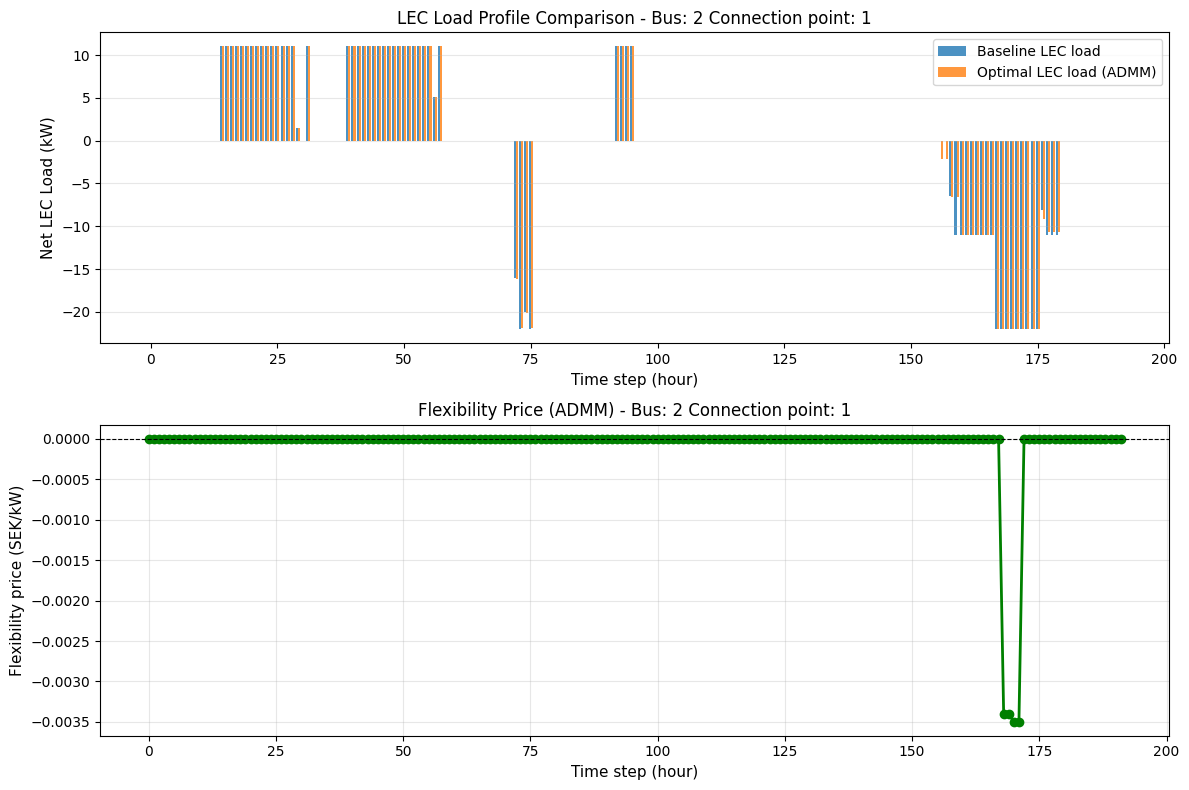



In bus: 2 and for connection point: 2

Baseline cost: 3846.49

Optimized cost: 3846.7

Delta: 0.21 SEK i.e., 0.01 %


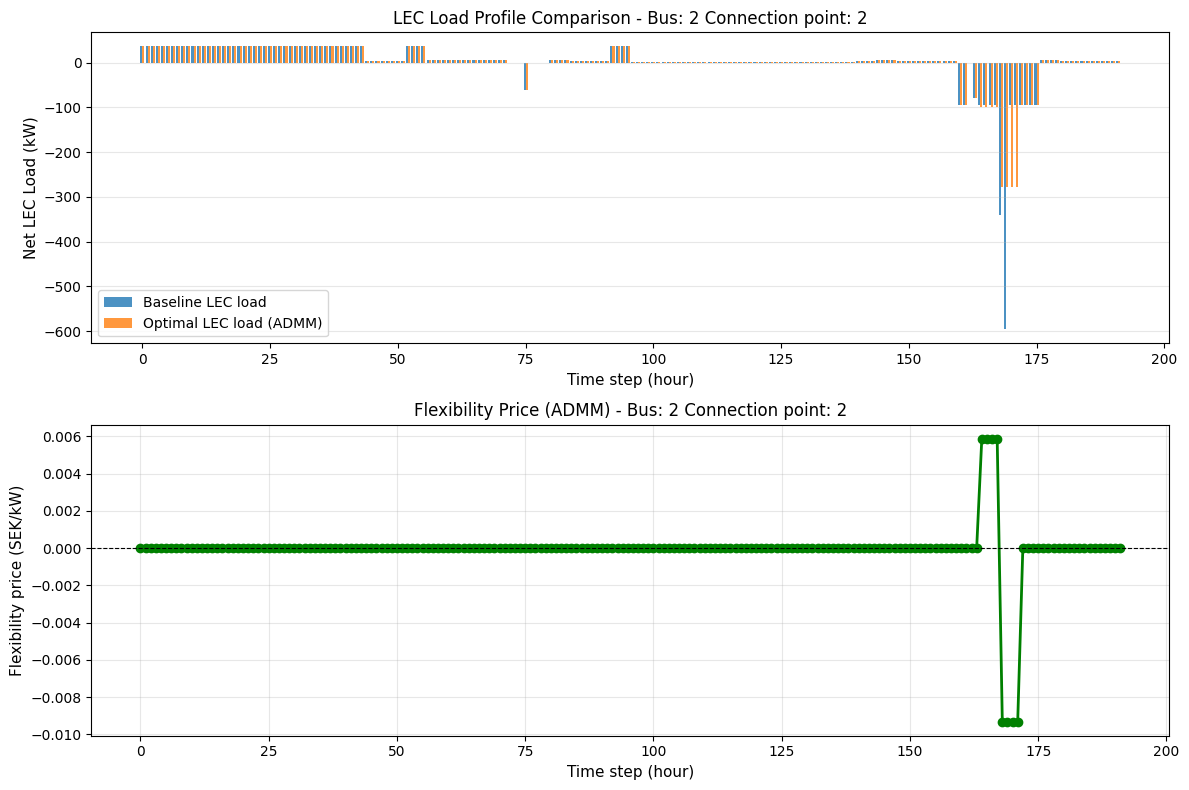

In [ ]:
for bus in rolling_results_dict:
    for connection_point in rolling_results_dict[bus]:
        print(f"\n\nIn bus: {bus} and for connection point: {connection_point}\n")
        baseline_results_dict[bus][connection_point], rolling_results_dict[bus][connection_point] = cost_calculation(baseline_results_dict[bus][connection_point], rolling_results_dict[bus][connection_point],
                                                                                                                     subscription_fee, peak_effect_fee, energy_tax, resolution)
        plot_results(baseline_results_dict[bus][connection_point], rolling_results_dict[bus][connection_point], bus, connection_point)